#### 시너지별 승률 기준으로 이상치 찾기
- Isolation Forest

In [3]:
# 데이터 호출
import pandas as pd

df_combination = pd.read_csv('../../stats_csv/유저단위_게임데이터_상위랭커보존-stats_champion_1.csv')


In [4]:
print(df_combination.info())

display(df_combination.head(1))

<class 'pandas.DataFrame'>
RangeIndex: 396204 entries, 0 to 396203
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   user_id           396204 non-null  str  
 1   game_id           396204 non-null  str  
 2   user_tier         396204 non-null  str  
 3   ranked            396204 non-null  int64
 4   flag_1            396204 non-null  int64
 5   flag_2            396204 non-null  int64
 6   active_synergies  396204 non-null  str  
 7   top4_flag         396204 non-null  bool 
 8   ranked_1          396204 non-null  bool 
 9   champions         396204 non-null  str  
dtypes: bool(2), int64(3), str(5)
memory usage: 24.9 MB
None


,user_id,game_id,user_tier,ranked,flag_1,flag_2,active_synergies,top4_flag,ranked_1,champions
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,"[{'name': 'ziggs', 'star': 1, 'cost': 1, 'orig..."


In [5]:
# game_id별 유저 수 확인
game_user_count = df_combination.groupby('game_id')['user_id'].nunique()

# 8명이 참여한 게임만 추출
valid_games = game_user_count[game_user_count == 8].index

# 필터링
df_combo_valid = df_combination[df_combination['game_id'].isin(valid_games)]

print(f'전체 게임 수: {df_combination["game_id"].nunique()}')
print(f'8명 풀게임 수: {df_combo_valid["game_id"].nunique()}')
print(f'필터링 후 행 수: {len(df_combo_valid)}')

전체 게임 수: 49562
8명 풀게임 수: 49339
필터링 후 행 수: 394712


In [6]:
import ast

# active_synergies 파싱
df_combo_valid['active_synergies'] = df_combo_valid['active_synergies'].apply(ast.literal_eval)

# 조합 리스트 추출
df_combo_valid['combo_list_active'] = df_combo_valid['active_synergies'].apply(
    lambda x: list(x.keys()) if x else []
)

# 시너지 단위로 explode
df_combo_exploded = df_combo_valid.explode('combo_list_active')

# 빈 값 제거
df_combo_exploded = df_combo_exploded[df_combo_exploded['combo_list_active'] != '']

print(df_combo_exploded.shape)

(1767954, 11)


In [7]:
# 시너지별 통계 집계 (8명 풀게임 기준)
total_user_games_valid = len(df_combo_valid[['game_id', 'user_id']].drop_duplicates())

combo_stats_valid = df_combo_exploded.groupby('combo_list_active').agg(
    pick_count=('combo_list_active', 'count'),
    avg_rank=('ranked', 'mean'),
    win_rate=('ranked_1', 'mean'),
    top4_rate=('top4_flag', 'mean')
).reset_index()

# 픽률 계산
combo_stats_valid['pick_rate'] = combo_stats_valid['pick_count'] / total_user_games_valid

display(combo_stats_valid.head(5))

,combo_list_active,pick_count,avg_rank,win_rate,top4_rate,pick_rate
0,Blademaster,103599,4.425207,0.127858,0.513480,0.262467
1,Blaster,115114,4.263044,0.129142,0.544869,0.291640
2,Brawler,100733,4.335233,0.122095,0.532596,0.255206
3,Celestial,136704,4.288075,0.142359,0.538068,0.346339
4,Chrono,199760,4.245925,0.138256,0.548463,0.506091


In [8]:
combo_stats_valid.to_csv('../../stats_csv/combination_stats_by_full_game(ML).csv', index=False, encoding='utf-8-sig')

---

#### Isolation_Forest를 사용해서 이상치 탐색하기

##### Isolation_Forest에서 피처의 의미

- 피처로 선택한 변수들을 기준으로 "다른 데이터와 얼마나 다른가"를 측정
- 피처가 많을수록 → 여러 변수를 종합해서 이상치 판단
- 피처가 적을수록 → 특정 변수에 집중해서 이상치 판단

In [9]:
# 라이브러리 호출
from sklearn.ensemble import IsolationForest


random_seed = 42

In [10]:
# 피처 선택
X = combo_stats_valid[['win_rate', 'pick_rate']]

In [11]:
# Isolation_Forest 모델 정의

iso_forest_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

# anomaly: Isolation Forest가 각 데이터를 분류한 결과
    # 1 → 정상 (다른 시너지들과 비슷한 패턴)
    # -1 → 이상치 (다른 시너지들과 패턴이 다름)
    
# anomaly_score: 각 데이터가 얼마나 이상치에 가까운지를 나타내는 점수
    # 0에 가까울수록 → 정상
    # 음수일수록 → 이상치에 가까움

In [12]:
# 이상치 탐지
combo_stats_valid['anomaly'] = iso_forest_model.fit_predict(X)
combo_stats_valid['anomaly_score'] = iso_forest_model.score_samples(X)

# 결과 확인
print(f'이상치 개수: {(combo_stats_valid["anomaly"] == -1).sum()}')
print(f'정상 개수: {(combo_stats_valid["anomaly"] == 1).sum()}')
display(combo_stats_valid.sort_values('anomaly_score'))

이상치 개수: 2
정상 개수: 21


,combo_list_active,pick_count,avg_rank,win_rate,top4_rate,pick_rate,anomaly,anomaly_score
19,Starship,23045,3.540291,0.199479,0.688349,0.058384,-1,-0.663499
4,Chrono,199760,4.245925,0.138256,0.548463,0.506091,-1,-0.651273
12,Mystic,66759,3.999536,0.186252,0.589658,0.169133,1,-0.563251
11,Mercenary,126650,3.942771,0.158745,0.605424,0.320867,1,-0.515432
22,Void,19249,4.248532,0.143280,0.543509,0.048767,1,-0.513082
2,Brawler,100733,4.335233,0.122095,0.532596,0.255206,1,-0.510324
5,Cybernetic,41514,4.466301,0.123717,0.506504,0.105175,1,-0.504016
3,Celestial,136704,4.288075,0.142359,0.538068,0.346339,1,-0.497605
1,Blaster,115114,4.263044,0.129142,0.544869,0.291640,1,-0.488223
7,Demolitionist,45797,4.092473,0.170579,0.570845,0.116026,1,-0.478789


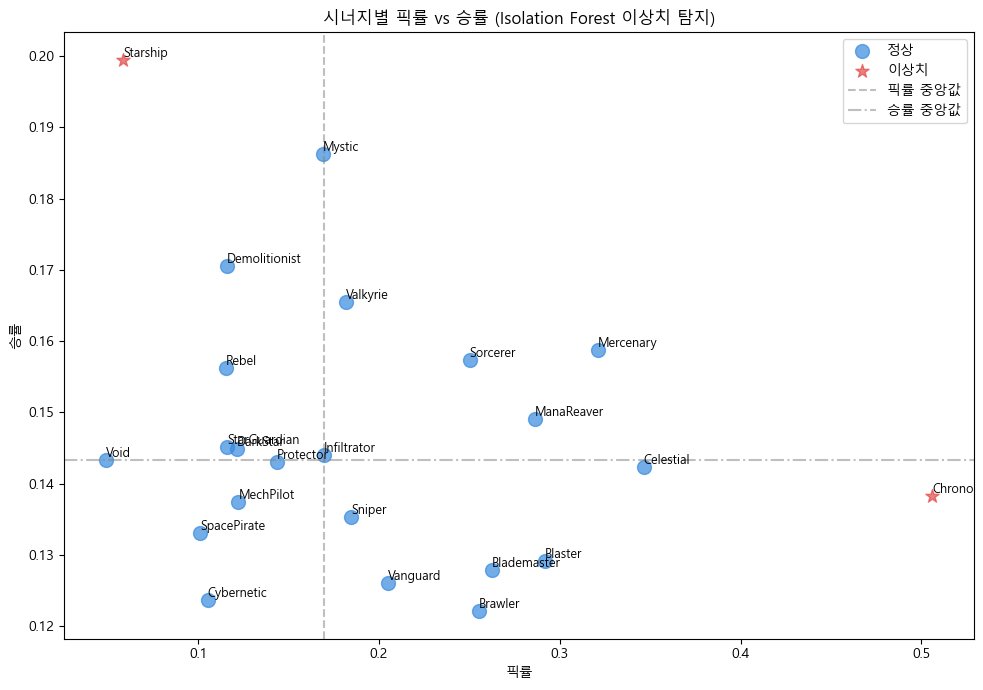

In [13]:
import matplotlib.pyplot as plt
import platform
    
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 7))

# 정상 / 이상치 분리
normal = combo_stats_valid[combo_stats_valid['anomaly'] == 1]
anomaly = combo_stats_valid[combo_stats_valid['anomaly'] == -1]

# 정상 산점도
ax.scatter(normal['pick_rate'], normal['win_rate'], 
        c='#378ADD', label='정상', alpha=0.7, s=100)

# 이상치 산점도
ax.scatter(anomaly['pick_rate'], anomaly['win_rate'], 
        c='#E24B4A', label='이상치', alpha=0.7, s=100, marker='*')

# 시너지 이름 표시
for _, row in combo_stats_valid.iterrows():
        ax.annotate(row['combo_list_active'], 
                        (row['pick_rate'], row['win_rate']),
                        fontsize=9, ha='left', va='bottom')

# 기준선 (중앙값)
ax.axvline(combo_stats_valid['pick_rate'].median(), 
        color='gray', linestyle='--', alpha=0.5, label='픽률 중앙값')
ax.axhline(combo_stats_valid['win_rate'].median(), 
        color='gray', linestyle='-.', alpha=0.5, label='승률 중앙값')

ax.set_xlabel('픽률')
ax.set_ylabel('승률')
ax.set_title('시너지별 픽률 vs 승률 (Isolation Forest 이상치 탐지)')
ax.legend()

plt.tight_layout()
plt.show()

In [14]:
print(f'contamination: {iso_forest_model.contamination}')
print(f'전체 시너지 수: {len(combo_stats_valid)}')
print(f'이상치 개수: {(combo_stats_valid["anomaly"] == -1).sum()}')
print(f'이상치 비율: {(combo_stats_valid["anomaly"] == -1).sum() / len(combo_stats_valid):.2%}')

contamination: 0.05
전체 시너지 수: 23
이상치 개수: 2
이상치 비율: 8.70%


---
#### 이상치 기준 튜닝
- contamination 값을 바꿔가면서 탐색
- 데이터프레임: `combo_stats_valid` 사용 (콤비네이션)

In [15]:
# ================================
# 파라미터 튜닝 함수
# ================================
contamination_list = [0.01, 0.03, 0.05, 0.09, 0.11]
combo_tuning_results = []

for c in contamination_list:
    model = IsolationForest(contamination=c, random_state=42)
    labels = model.fit_predict(combo_stats_valid[['win_rate', 'pick_rate']])
    outlier_df = combo_stats_valid[labels == -1].copy()
    combo_tuning_results.append({
        'contamination': c,
        'n_outliers': len(outlier_df),
        'outliers': outlier_df['combo_list_active'].tolist()
    })
    print(f"contamination={c:.2f} → 이상치 {len(outlier_df)}개 | {outlier_df['combo_list_active'].tolist()}")

combo_tuning_df = pd.DataFrame(combo_tuning_results)

# ================================
# 공통 이상치 분석
# ================================
print("\n===== 공통 이상치 분석 (시너지) =====")
all_outliers = [name for outliers in combo_tuning_df['outliers'] for name in outliers]
common = pd.Series(all_outliers).value_counts()
common = common[common >= len(contamination_list) // 2]
print(common)

contamination=0.01 → 이상치 1개 | ['Starship']
contamination=0.03 → 이상치 1개 | ['Starship']
contamination=0.05 → 이상치 2개 | ['Chrono', 'Starship']
contamination=0.09 → 이상치 2개 | ['Chrono', 'Starship']
contamination=0.11 → 이상치 3개 | ['Chrono', 'Mystic', 'Starship']

===== 공통 이상치 분석 (시너지) =====
Starship    5
Chrono      3
Name: count, dtype: int64


---
##### 이상치 탐색 - 평균 등수와 선택률 기준

In [16]:
# 피처 선택
X_champ_1 = combo_stats_valid[['avg_rank', 'pick_rate']]

# Isolation_Forest 모델 정의
iso_forest_champ_1 = IsolationForest(
    contamination=0.05,
    random_state=42
)

# 이상치 탐지
combo_stats_valid['anomaly'] = iso_forest_champ_1.fit_predict(X_champ_1)
combo_stats_valid['anomaly_score'] = iso_forest_champ_1.score_samples(X_champ_1)

# 결과 확인
print(f'전체 시너지 수: {len(combo_stats_valid)}')
print(f'이상치 개수: {(combo_stats_valid["anomaly"] == -1).sum()}')
print(f'이상치 비율: {(combo_stats_valid["anomaly"] == -1).sum() / len(combo_stats_valid):.2%}')
display(combo_stats_valid[combo_stats_valid['anomaly'] == -1].sort_values('anomaly_score'))

전체 시너지 수: 23
이상치 개수: 2
이상치 비율: 8.70%


,combo_list_active,pick_count,avg_rank,win_rate,top4_rate,pick_rate,anomaly,anomaly_score
19,Starship,23045,3.540291,0.199479,0.688349,0.058384,-1,-0.699804
4,Chrono,199760,4.245925,0.138256,0.548463,0.506091,-1,-0.659509


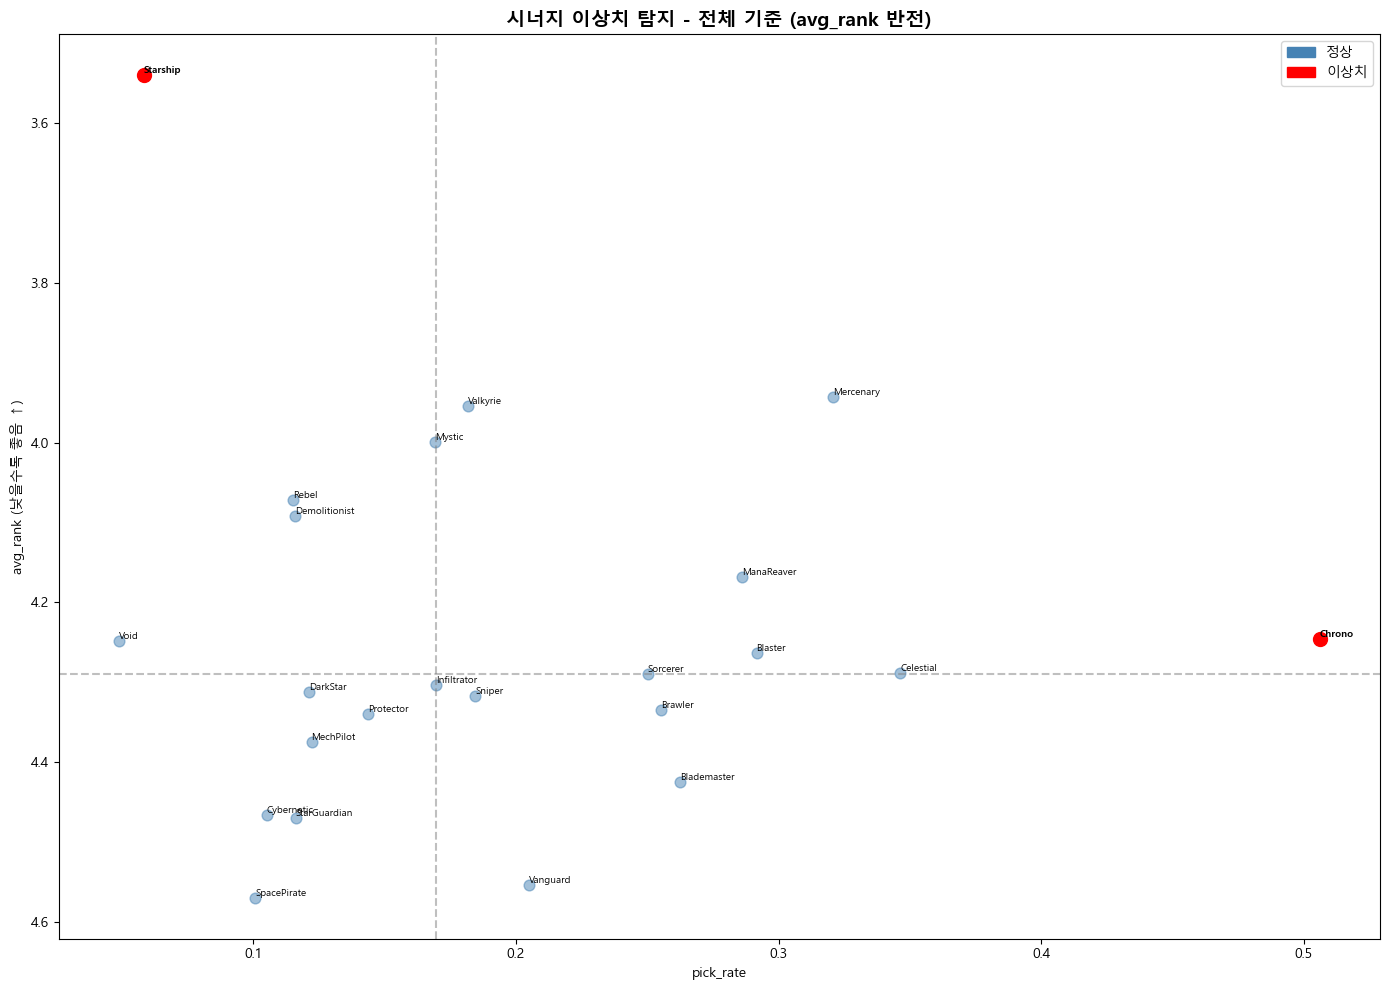

In [17]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 10))

# 정상 / 이상치 분리
normal  = combo_stats_valid[combo_stats_valid['anomaly'] == 1]
outlier = combo_stats_valid[combo_stats_valid['anomaly'] == -1]

# 산점도
ax.scatter(normal['pick_rate'],  normal['avg_rank'],
        color='steelblue', alpha=0.5, s=60, label='정상')
ax.scatter(outlier['pick_rate'], outlier['avg_rank'],
        color='red', s=100, label='이상치')

# 챔피언 이름 표시
for _, row in combo_stats_valid.iterrows():
    ax.annotate(row['combo_list_active'], (row['pick_rate'], row['avg_rank']),
                fontsize=7, ha='left', va='bottom',
                fontweight='bold' if row['anomaly'] == -1 else 'normal')

# y축 반전
ax.invert_yaxis()

# 기준선 (전체 중앙값)
ax.axvline(x=combo_stats_valid['pick_rate'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=combo_stats_valid['avg_rank'].median(),  color='gray', linestyle='--', alpha=0.5)

ax.set_title('시너지 이상치 탐지 - 전체 기준 (avg_rank 반전)', fontsize=14, fontweight='bold')
ax.set_xlabel('pick_rate')
ax.set_ylabel('avg_rank (낮을수록 좋음 ↑)')

patches = [
    mpatches.Patch(color='steelblue', label='정상'),
    mpatches.Patch(color='red',       label='이상치')
]
ax.legend(handles=patches, fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
# ================================
# 파라미터 튜닝
# ================================
contamination_list_1 = [0.01, 0.03, 0.05, 0.07, 0.09, 0.11]
champ_tuning_results_1 = []

for c in contamination_list_1:
    model_1 = IsolationForest(contamination=c, random_state=42)
    labels_1 = model_1.fit_predict(combo_stats_valid[['avg_rank', 'pick_rate']])
    outlier_df_1 = combo_stats_valid[labels_1 == -1].copy()
    champ_tuning_results_1.append({
        'contamination': c,
        'n_outliers': len(outlier_df_1),
        'outliers': outlier_df_1['combo_list_active'].tolist()
    })
    print(f"contamination={c:.2f} → 이상치 {len(outlier_df_1)}개 | {outlier_df_1['combo_list_active'].tolist()}")

champ_tuning_df_1 = pd.DataFrame(champ_tuning_results_1)

# ================================
# 공통 이상치 분석
# ================================
print("\n===== 공통 이상치 분석 (시너지) =====")
all_outliers_1 = [combo_list_active for outliers in champ_tuning_df_1['outliers'] for combo_list_active in outliers]
common_1 = pd.Series(all_outliers_1).value_counts()
common_1 = common_1[common_1 >= len(contamination_list_1) // 2]
print(common_1)

contamination=0.01 → 이상치 1개 | ['Starship']
contamination=0.03 → 이상치 1개 | ['Starship']
contamination=0.05 → 이상치 2개 | ['Chrono', 'Starship']
contamination=0.07 → 이상치 2개 | ['Chrono', 'Starship']
contamination=0.09 → 이상치 2개 | ['Chrono', 'Starship']
contamination=0.11 → 이상치 3개 | ['Chrono', 'Mercenary', 'Starship']

===== 공통 이상치 분석 (시너지) =====
Starship    6
Chrono      4
Name: count, dtype: int64


---
#### Starship 지운 결과

##### y축 승률 & 픽률 : (StarShip 지운 결과)

In [19]:
# 데이터 호출

combo_stats_valid_re = pd.read_csv('../../stats_csv/combination_stats_by_full_game(ML).csv')


In [20]:
# star ship 지우기
combo_stats_valid_except = combo_stats_valid_re.drop(
    combo_stats_valid_re[combo_stats_valid_re['combo_list_active'] == 'Starship'].index
)

In [21]:
print("Starship 남은 개수:", (combo_stats_valid_except['combo_list_active'] == 'Starship').sum())

Starship 남은 개수: 0


In [22]:
# 라이브러리 호출
from sklearn.ensemble import IsolationForest
random_seed = 42

# 피처 선택
X = combo_stats_valid_except[['win_rate', 'pick_rate']]

In [23]:
# Isolation_Forest 모델 정의

iso_forest_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

# anomaly: Isolation Forest가 각 데이터를 분류한 결과
    # 1 → 정상 (다른 시너지들과 비슷한 패턴)
    # -1 → 이상치 (다른 시너지들과 패턴이 다름)
    
# anomaly_score: 각 데이터가 얼마나 이상치에 가까운지를 나타내는 점수
    # 0에 가까울수록 → 정상
    # 음수일수록 → 이상치에 가까움
    

In [24]:
# 이상치 탐지
combo_stats_valid_except['anomaly'] = iso_forest_model.fit_predict(X)
combo_stats_valid_except['anomaly_score'] = iso_forest_model.score_samples(X)

# 결과 확인
print(f'이상치 개수: {(combo_stats_valid_except["anomaly"] == -1).sum()}')
print(f'정상 개수: {(combo_stats_valid_except["anomaly"] == 1).sum()}')
display(combo_stats_valid_except.sort_values('anomaly_score'))

이상치 개수: 2
정상 개수: 20


,combo_list_active,pick_count,avg_rank,win_rate,top4_rate,pick_rate,anomaly,anomaly_score
4,Chrono,199760,4.245925,0.138256,0.548463,0.506091,-1,-0.659355
12,Mystic,66759,3.999536,0.186252,0.589658,0.169133,-1,-0.602956
22,Void,19249,4.248532,0.143280,0.543509,0.048767,1,-0.531400
11,Mercenary,126650,3.942771,0.158745,0.605424,0.320867,1,-0.520062
2,Brawler,100733,4.335233,0.122095,0.532596,0.255206,1,-0.511772
3,Celestial,136704,4.288075,0.142359,0.538068,0.346339,1,-0.510616
7,Demolitionist,45797,4.092473,0.170579,0.570845,0.116026,1,-0.507190
5,Cybernetic,41514,4.466301,0.123717,0.506504,0.105175,1,-0.504132
1,Blaster,115114,4.263044,0.129142,0.544869,0.291640,1,-0.489220
21,Vanguard,80861,4.553691,0.126081,0.488789,0.204861,1,-0.479740


In [25]:
# 결과 확인
print(f'이상치 개수: {(combo_stats_valid_except["anomaly"] == -1).sum()}')
print(f'정상 개수: {(combo_stats_valid_except["anomaly"] == 1).sum()}')
display(combo_stats_valid_except.sort_values('anomaly_score'))

이상치 개수: 2
정상 개수: 20


,combo_list_active,pick_count,avg_rank,win_rate,top4_rate,pick_rate,anomaly,anomaly_score
4,Chrono,199760,4.245925,0.138256,0.548463,0.506091,-1,-0.659355
12,Mystic,66759,3.999536,0.186252,0.589658,0.169133,-1,-0.602956
22,Void,19249,4.248532,0.143280,0.543509,0.048767,1,-0.531400
11,Mercenary,126650,3.942771,0.158745,0.605424,0.320867,1,-0.520062
2,Brawler,100733,4.335233,0.122095,0.532596,0.255206,1,-0.511772
3,Celestial,136704,4.288075,0.142359,0.538068,0.346339,1,-0.510616
7,Demolitionist,45797,4.092473,0.170579,0.570845,0.116026,1,-0.507190
5,Cybernetic,41514,4.466301,0.123717,0.506504,0.105175,1,-0.504132
1,Blaster,115114,4.263044,0.129142,0.544869,0.291640,1,-0.489220
21,Vanguard,80861,4.553691,0.126081,0.488789,0.204861,1,-0.479740


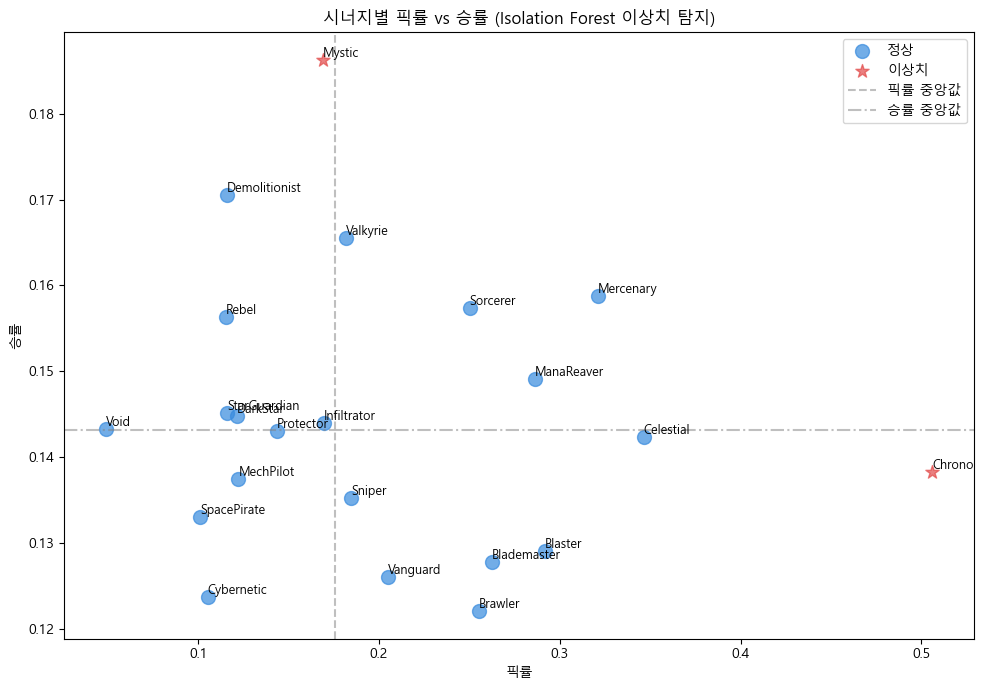

contamination: 0.05
전체 시너지 수: 22
이상치 개수: 2
이상치 비율: 9.09%


In [26]:
import matplotlib.pyplot as plt
import platform
    
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 7))

# 정상 / 이상치 분리
normal = combo_stats_valid_except[combo_stats_valid_except['anomaly'] == 1]
anomaly = combo_stats_valid_except[combo_stats_valid_except['anomaly'] == -1]

# 정상 산점도
ax.scatter(normal['pick_rate'], normal['win_rate'], 
        c='#378ADD', label='정상', alpha=0.7, s=100)

# 이상치 산점도
ax.scatter(anomaly['pick_rate'], anomaly['win_rate'], 
        c='#E24B4A', label='이상치', alpha=0.7, s=100, marker='*')

# 시너지 이름 표시
for _, row in combo_stats_valid_except.iterrows():
        ax.annotate(row['combo_list_active'], 
                        (row['pick_rate'], row['win_rate']),
                        fontsize=9, ha='left', va='bottom')

# 기준선 (중앙값)
ax.axvline(combo_stats_valid_except['pick_rate'].median(), 
        color='gray', linestyle='--', alpha=0.5, label='픽률 중앙값')
ax.axhline(combo_stats_valid_except['win_rate'].median(), 
        color='gray', linestyle='-.', alpha=0.5, label='승률 중앙값')

ax.set_xlabel('픽률')
ax.set_ylabel('승률')
ax.set_title('시너지별 픽률 vs 승률 (Isolation Forest 이상치 탐지)')
ax.legend()

plt.tight_layout()
plt.show()


print(f'contamination: {iso_forest_model.contamination}')
print(f'전체 시너지 수: {len(combo_stats_valid_except)}')
print(f'이상치 개수: {(combo_stats_valid_except["anomaly"] == -1).sum()}')
print(f'이상치 비율: {(combo_stats_valid_except["anomaly"] == -1).sum() / len(combo_stats_valid_except):.2%}')


In [27]:
# ================================
# 파라미터 튜닝 함수
# ================================
contamination_list = [0.01, 0.03, 0.05, 0.07, 0.09, 0.11]
combo_tuning_results = []

for c in contamination_list:
    model = IsolationForest(contamination=c, random_state=42)
    labels = model.fit_predict(combo_stats_valid_except[['win_rate', 'pick_rate']])
    outlier_df = combo_stats_valid_except[labels == -1].copy()
    combo_tuning_results.append({
        'contamination': c,
        'n_outliers': len(outlier_df),
        'outliers': outlier_df['combo_list_active'].tolist()
    })
    print(f"contamination={c:.2f} → 이상치 {len(outlier_df)}개 | {outlier_df['combo_list_active'].tolist()}")

combo_tuning_df_re = pd.DataFrame(combo_tuning_results)

contamination=0.01 → 이상치 1개 | ['Chrono']
contamination=0.03 → 이상치 1개 | ['Chrono']
contamination=0.05 → 이상치 2개 | ['Chrono', 'Mystic']
contamination=0.07 → 이상치 2개 | ['Chrono', 'Mystic']
contamination=0.09 → 이상치 2개 | ['Chrono', 'Mystic']
contamination=0.11 → 이상치 3개 | ['Chrono', 'Mystic', 'Void']


In [28]:
# ================================
# 공통 이상치 분석
# ================================
print("\n===== 공통 이상치 분석 (시너지) =====")
all_outliers = [name for outliers in combo_tuning_df_re['outliers'] for name in outliers]
common = pd.Series(all_outliers).value_counts()
common = common[common >= len(contamination_list) // 2]
print(common)


===== 공통 이상치 분석 (시너지) =====
Chrono    6
Mystic    4
Name: count, dtype: int64


##### y축 평균등수 & 픽률 : (StarShip 지운 결과)

In [29]:
# 피처 선택
X_champ_1 = combo_stats_valid_except[['avg_rank', 'pick_rate']]

# Isolation_Forest 모델 정의
iso_forest_champ_1 = IsolationForest(
    contamination=0.05,
    random_state=42
)

In [30]:
# 이상치 탐지
combo_stats_valid_except['anomaly'] = iso_forest_champ_1.fit_predict(X_champ_1)
combo_stats_valid_except['anomaly_score'] = iso_forest_champ_1.score_samples(X_champ_1)

# 결과 확인
print(f'전체 시너지 수: {len(combo_stats_valid_except)}')
print(f'이상치 개수: {(combo_stats_valid_except["anomaly"] == -1).sum()}')
print(f'이상치 비율: {(combo_stats_valid_except["anomaly"] == -1).sum() / len(combo_stats_valid_except):.2%}')
display(combo_stats_valid_except[combo_stats_valid_except['anomaly'] == -1].sort_values('anomaly_score'))


전체 시너지 수: 22
이상치 개수: 2
이상치 비율: 9.09%


,combo_list_active,pick_count,avg_rank,win_rate,top4_rate,pick_rate,anomaly,anomaly_score
4,Chrono,199760,4.245925,0.138256,0.548463,0.506091,-1,-0.651713
11,Mercenary,126650,3.942771,0.158745,0.605424,0.320867,-1,-0.604777


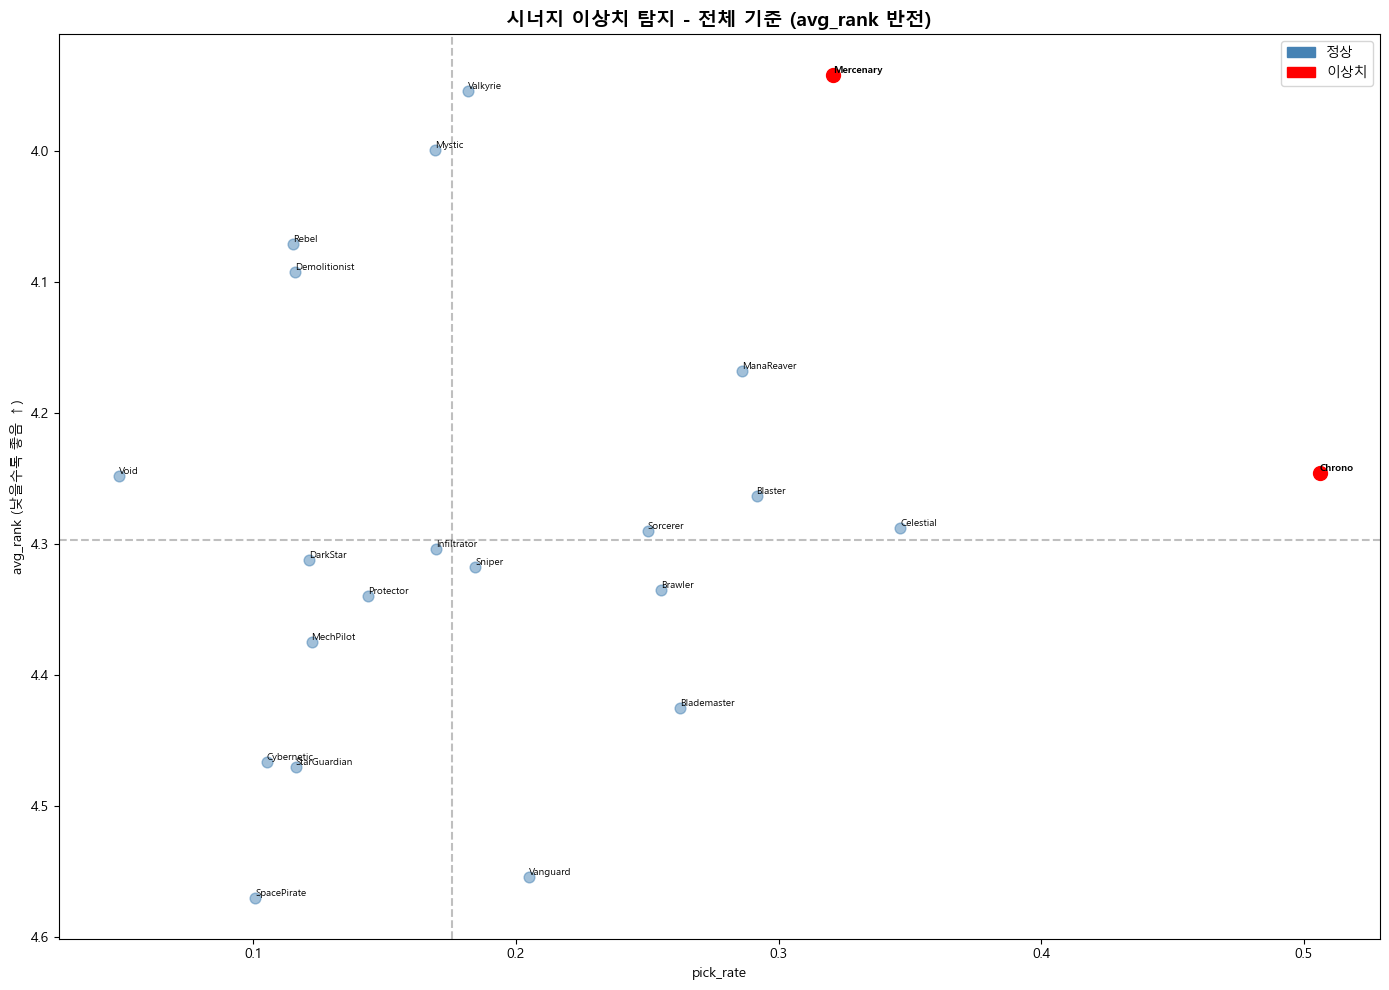

In [31]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 10))

# 정상 / 이상치 분리
normal  = combo_stats_valid_except[combo_stats_valid_except['anomaly'] == 1]
outlier = combo_stats_valid_except[combo_stats_valid_except['anomaly'] == -1]

# 산점도
ax.scatter(normal['pick_rate'],  normal['avg_rank'],
        color='steelblue', alpha=0.5, s=60, label='정상')
ax.scatter(outlier['pick_rate'], outlier['avg_rank'],
        color='red', s=100, label='이상치')

# 챔피언 이름 표시
for _, row in combo_stats_valid_except.iterrows():
    ax.annotate(row['combo_list_active'], (row['pick_rate'], row['avg_rank']),
                fontsize=7, ha='left', va='bottom',
                fontweight='bold' if row['anomaly'] == -1 else 'normal')

# y축 반전
ax.invert_yaxis()

# 기준선 (전체 중앙값)
ax.axvline(x=combo_stats_valid_except['pick_rate'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=combo_stats_valid_except['avg_rank'].median(),  color='gray', linestyle='--', alpha=0.5)

ax.set_title('시너지 이상치 탐지 - 전체 기준 (avg_rank 반전)', fontsize=14, fontweight='bold')
ax.set_xlabel('pick_rate')
ax.set_ylabel('avg_rank (낮을수록 좋음 ↑)')

patches = [
    mpatches.Patch(color='steelblue', label='정상'),
    mpatches.Patch(color='red',       label='이상치')
]
ax.legend(handles=patches, fontsize=10)

plt.tight_layout()
plt.show()



In [32]:
# ================================
# 파라미터 튜닝
# ================================
contamination_list_1 = [0.01, 0.03, 0.05, 0.07, 0.09, 0.11]
champ_tuning_results_1 = []

for c in contamination_list_1:
    model_1 = IsolationForest(contamination=c, random_state=42)
    labels_1 = model_1.fit_predict(combo_stats_valid_except[['avg_rank', 'pick_rate']])
    outlier_df_1 = combo_stats_valid_except[labels_1 == -1].copy()
    champ_tuning_results_1.append({
        'contamination': c,
        'n_outliers': len(outlier_df_1),
        'outliers': outlier_df_1['combo_list_active'].tolist()
    })
    print(f"contamination={c:.2f} → 이상치 {len(outlier_df_1)}개 | {outlier_df_1['combo_list_active'].tolist()}")

champ_tuning_df_re_2 = pd.DataFrame(champ_tuning_results_1)


contamination=0.01 → 이상치 1개 | ['Chrono']
contamination=0.03 → 이상치 1개 | ['Chrono']
contamination=0.05 → 이상치 2개 | ['Chrono', 'Mercenary']
contamination=0.07 → 이상치 2개 | ['Chrono', 'Mercenary']
contamination=0.09 → 이상치 2개 | ['Chrono', 'Mercenary']
contamination=0.11 → 이상치 3개 | ['Chrono', 'Mercenary', 'Vanguard']


In [ ]:
# # ================================
# # 공통 이상치 분석
# # ================================
# print("\n===== 공통 이상치 분석 (시너지) =====")
# all_outliers_1 = [combo_list_active for outliers in champ_tuning_df_re_2['outliers'] for combo_list_active in outliers]
# common_1 = pd.Series(all_outliers_1).value_counts()
# common_1 = common_1[common_1 >= len(contamination_list_1) // 2]
# print(common_1)


===== 공통 이상치 분석 (시너지) =====
Chrono       6
Mercenary    4
Name: count, dtype: int64


In [ ]:
# # 필요한 컬럼 선택
# combination_stats_abnoraml = combo_stats_valid_except[[
#     'combo_list_active',      # 시너지/합성명
#     'avg_rank',               # 평균 순위
#     'pick_rate',              # 픽률
#     'win_rate',               # 승률
#     'anomaly'                 # 이상치 판정 (-1 또는 1)
# ]].reset_index(drop=True)
 
# # 확인
# combination_stats_abnoraml

,combo_list_active,avg_rank,pick_rate,win_rate,anomaly
0,Blademaster,4.425207,0.262467,0.127858,1
1,Blaster,4.263044,0.291640,0.129142,1
2,Brawler,4.335233,0.255206,0.122095,1
3,Celestial,4.288075,0.346339,0.142359,1
4,Chrono,4.245925,0.506091,0.138256,-1
5,Cybernetic,4.466301,0.105175,0.123717,1
6,DarkStar,4.312437,0.121405,0.144846,1
7,Demolitionist,4.092473,0.116026,0.170579,1
8,Infiltrator,4.303607,0.169605,0.144044,1
9,ManaReaver,4.168241,0.286100,0.149105,1


In [ ]:
# # -1을 1로, 1을 0으로 변환
# combination_stats_abnoraml['anomaly'] = combination_stats_abnoraml['anomaly'].map({-1: 1, 1: 0})

In [ ]:

# v3_anomalies = combination_stats_abnoraml[combination_stats_abnoraml['anomaly'] == 1]
# v3_anomalies

,combo_list_active,avg_rank,pick_rate,win_rate,anomaly
4,Chrono,4.245925,0.506091,0.138256,1
11,Mercenary,3.942771,0.320867,0.158745,1


In [ ]:
# v3_anomalies.to_csv('combo_abnormal.csv', index=False, encoding='utf-8-sig')